Name: Tharun Otturu   
Assignment Title: The EDA Checklist

### Generating the Dataset

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


### Task 1

In [19]:
print(f"The shape of the dataframe is: {df.shape}")
print(f"\nThe datatypes of the columns: \n")
print(df.dtypes)

print(f"\nNumber of missing values in each columns: \n")
print(df.isnull().sum())

print(f"\nPercentage of missing values in each column: ")

(df.isnull().sum() / len(df)) * 100

The shape of the dataframe is: (200, 6)

The datatypes of the columns: 

order_id           int64
city                 str
category             str
order_value      float64
delivery_days    float64
rating            object
dtype: object

Number of missing values in each columns: 

order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Percentage of missing values in each column: 


order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64

### Task 2

In [20]:
print(df.describe())

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


#### Observations
1. The order_value column shows a large gap between the 75th % percentile and the max. 
2. The mean of order_value column is also higher. This means that even though there are less records with value higher than 3987.5 (75th Percentile), their individual values are so high that the overall mean is also around the 75th percentile.


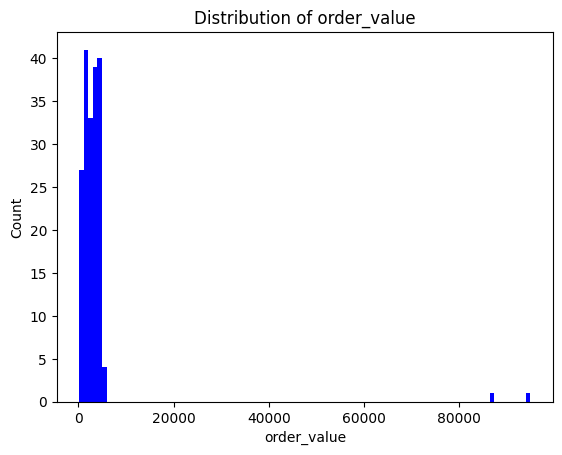

In [25]:

import matplotlib.pyplot as plt
import plotly.express as px



plt.hist(df["order_value"], bins=100, color="blue")

plt.title("Distribution of order_value")
plt.xlabel("order_value")
plt.ylabel("Count")
plt.show()


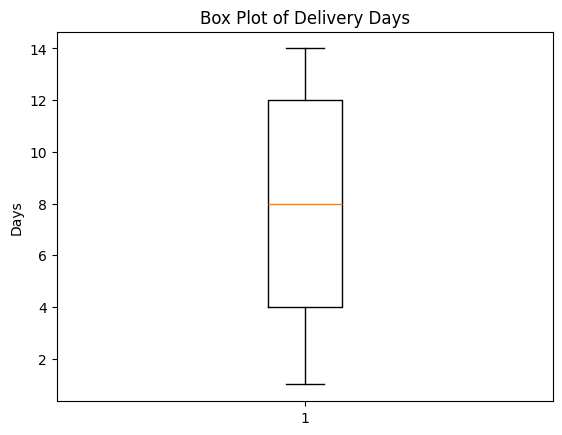

In [27]:
plt.figure()
plt.boxplot(df['delivery_days'].dropna())
plt.title("Box Plot of Delivery Days")
plt.ylabel("Days")
plt.show()



### Task 3

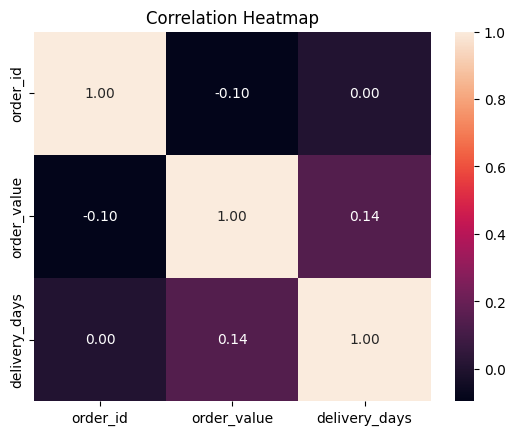

In [28]:
import seaborn as sns
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### Observations
1. There is zero correlation between order_id and delivery_days.
2. order_value and delivery_days seem to have slight correlation of 0.14 but nothing concrete.